# Practical 4: Google Stock Price Prediction using RNN

## Aim
Use Google stock prices to design a time series analysis and prediction system using a Recurrent Neural Network.

## Dataset
Local file used in this notebook: dl/4/goog.csv

## What you will learn
- How to load and sort time series data
- Why time series train/test split should not be random
- How to scale stock prices
- How to create look-back sequences
- How to train a SimpleRNN model
- How to plot actual vs predicted prices

Note: This notebook is for learning only, not financial advice. It uses TensorFlow/Keras and no PyTorch code.

In [13]:
# If imports fail on your machine, install these packages once:
# !pip install pandas numpy scikit-learn matplotlib tensorflow

In [14]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

## Step 1: Load and sort the data

For time series, order matters. We sort by Date before creating sequences.

In [15]:
DATA_PATH = Path("dl/4/goog.csv")

data = pd.read_csv(DATA_PATH)
data["Date"] = pd.to_datetime(data["Date"], errors="coerce")
data = data.dropna(subset=["Date", "Close"]).sort_values("Date").reset_index(drop=True)

print("Dataset shape:", data.shape)
data.head()

Dataset shape: (61, 6)


,Date,Open,High,Low,Close,Volume
0,2016-12-19,790.219971,797.659973,786.270020,794.200012,1225900
1,2016-12-20,796.760010,798.650024,793.270020,796.419983,925100
2,2016-12-21,795.840027,796.676025,787.099976,794.559998,1208700
3,2016-12-22,792.359985,793.320007,788.580017,791.260010,969100
4,2016-12-23,790.900024,792.739990,787.280029,789.909973,623400


In [16]:
data.describe()

,Date,Open,High,Low,Close,Volume
count,61,61.000000,61.000000,61.000000,61.000000,6.100000e+01
mean,2017-02-02 01:10:49.180327,814.005573,817.755576,809.734066,814.561804,1.361269e+06
min,2016-12-19 00:00:00,778.809998,782.780029,770.409973,771.820007,6.234000e+05
25%,2017-01-11 00:00:00,799.679993,802.700012,793.270020,801.340027,1.057900e+06
50%,2017-02-02 00:00:00,809.510010,815.250000,804.539978,809.559998,1.247700e+06
75%,2017-02-24 00:00:00,828.659973,833.250000,825.059998,830.630005,1.494500e+06
max,2017-03-17 00:00:00,851.609985,853.400024,847.109985,852.119995,3.228900e+06
std,NaN,18.784303,18.556004,19.384799,19.265955,4.987376e+05


## Step 2: Visualize closing price

We use the Close column as the value to predict.

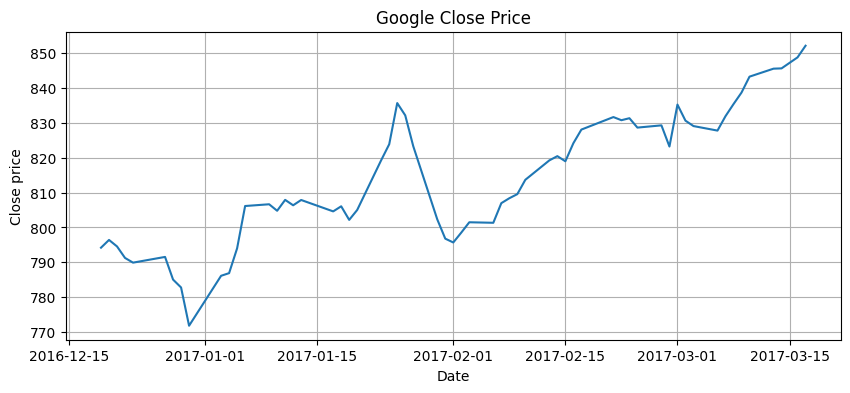

In [17]:
plt.figure(figsize=(10, 4))
plt.plot(data["Date"], data["Close"])
plt.xlabel("Date")
plt.ylabel("Close price")
plt.title("Google Close Price")
plt.grid(True)
plt.show()

## Step 3: Scale prices

RNNs train better when values are small. MinMaxScaler converts prices into the range 0 to 1.

In [18]:
close_prices = data[["Close"]].values.astype("float32")

scaler = MinMaxScaler(feature_range=(0, 1))
scaled_prices = scaler.fit_transform(close_prices)

print("Original first price:", close_prices[0][0])
print("Scaled first price:", scaled_prices[0][0])

Original first price: 794.2
Scaled first price: 0.27870464


## Step 4: Create sequences

For a full stock dataset, 60 previous days is common. This practical dataset is shortened, so the notebook automatically chooses a smaller look-back window that still creates enough training samples.

In [19]:
# A fixed LOOK_BACK = 60 gives zero training samples when the CSV is shortened.
# So we choose a small look-back automatically based on available rows.
max_possible_look_back = max(1, len(scaled_prices) - 2)
LOOK_BACK = min(10, max_possible_look_back)

print(f"Using LOOK_BACK = {LOOK_BACK} for {len(scaled_prices)} rows")

def create_sequences(values, look_back):
    if len(values) <= look_back:
        raise ValueError("Not enough rows to create RNN sequences. Use a smaller LOOK_BACK or more data.")

    X, y = [], []

    for i in range(look_back, len(values)):
        X.append(values[i - look_back:i, 0])
        y.append(values[i, 0])

    X = np.array(X)
    y = np.array(y)

    # RNN input shape: samples, time steps, features
    X = X.reshape(-1, look_back, 1)
    return X, y


X, y = create_sequences(scaled_prices, LOOK_BACK)

print("X shape:", X.shape)
print("y shape:", y.shape)

Using LOOK_BACK = 10 for 61 rows
X shape: (51, 10, 1)
y shape: (51,)


## Step 5: Time-based train/test split

We do not shuffle stock data. The first 80 percent is used for training and the last 20 percent for testing.

In [20]:
if len(X) < 2:
    raise ValueError("At least two sequences are required for train/test split. Add more rows or reduce LOOK_BACK.")

split_index = int(len(X) * 0.8)
split_index = max(1, min(split_index, len(X) - 1))

X_train, X_test = X[:split_index], X[split_index:]
y_train, y_test = y[:split_index], y[split_index:]

print("Train samples:", X_train.shape[0])
print("Test samples:", X_test.shape[0])

Train samples: 40
Test samples: 11


## Step 6: Build the RNN model

SimpleRNN is the basic recurrent layer. It reads one price at a time and keeps memory from previous time steps.

In [21]:
model = keras.Sequential([
    layers.Input(shape=(LOOK_BACK, 1)),
    layers.SimpleRNN(64, activation="tanh", return_sequences=True),
    layers.Dropout(0.2),
    layers.SimpleRNN(32, activation="tanh"),
    layers.Dense(1)
])

model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_2 (SimpleRNN)        │ (None, 10, 64)         │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 10, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_3 (SimpleRNN)        │ (None, 32)             │         3,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,361 (28.75 KB)

 Trainable params: 7,361 (28.75 KB)

 Non-trainable params: 0 (0.00 B)

## Step 7: Train the model

In [22]:
# Keras validation_split fails when training data is extremely small.
# We keep validation for normal cases and skip it only for tiny cut datasets.
validation_split = 0.1 if X_train.shape[0] >= 10 else 0.0
batch_size = min(16, X_train.shape[0])

history = model.fit(
    X_train,
    y_train,
    validation_split=validation_split,
    epochs=20,
    batch_size=batch_size,
    verbose=1
)

Epoch 1/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 148ms/step - loss: 0.1041 - mae: 0.2753 - val_loss: 0.0213 - val_mae: 0.1371
Epoch 2/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 0.1288 - mae: 0.2727 - val_loss: 0.0875 - val_mae: 0.2916
Epoch 3/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 0.0927 - mae: 0.2586 - val_loss: 0.0114 - val_mae: 0.0943
Epoch 4/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 0.0382 - mae: 0.1516 - val_loss: 0.0168 - val_mae: 0.1193
Epoch 5/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.0561 - mae: 0.2011 - val_loss: 0.0045 - val_mae: 0.0540
Epoch 6/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.0579 - mae: 0.1920 - val_loss: 0.0139 - val_mae: 0.1049
Epoch 7/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.0332 - mae: 0.1329 - val_loss: 0.0170 - val_mae: 0.1183
Epoch 8/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.0262 - mae: 0.1294 - val_loss: 0.0044 - val_mae: 0.0593
Epoch 9/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 0.0237 - mae: 0.1254 -

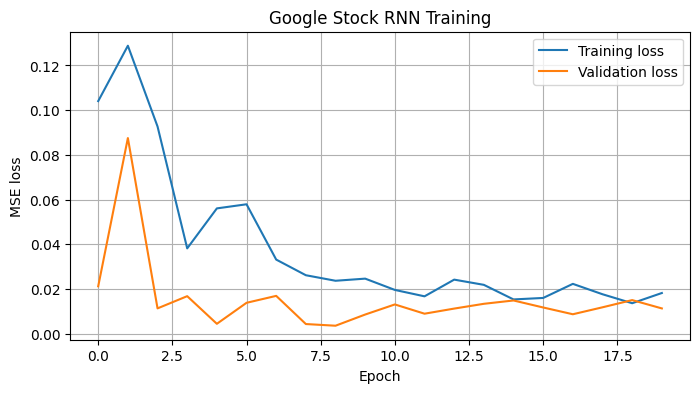

In [23]:
plt.figure(figsize=(8, 4))
plt.plot(history.history["loss"], label="Training loss")
if "val_loss" in history.history:
    plt.plot(history.history["val_loss"], label="Validation loss")
else:
    print("Validation loss was skipped because the training dataset is very small.")
plt.xlabel("Epoch")
plt.ylabel("MSE loss")
plt.title("Google Stock RNN Training")
plt.legend()
plt.grid(True)
plt.show()

## Step 8: Evaluate and convert predictions back to price scale

In [24]:
scaled_predictions = model.predict(X_test, verbose=0)

predicted_prices = scaler.inverse_transform(scaled_predictions)
actual_prices = scaler.inverse_transform(y_test.reshape(-1, 1))

mae = mean_absolute_error(actual_prices, predicted_prices)
rmse = np.sqrt(mean_squared_error(actual_prices, predicted_prices))

print(f"MAE  : {mae:.3f}")
print(f"RMSE : {rmse:.3f}")

MAE  : 14.360
RMSE : 16.031


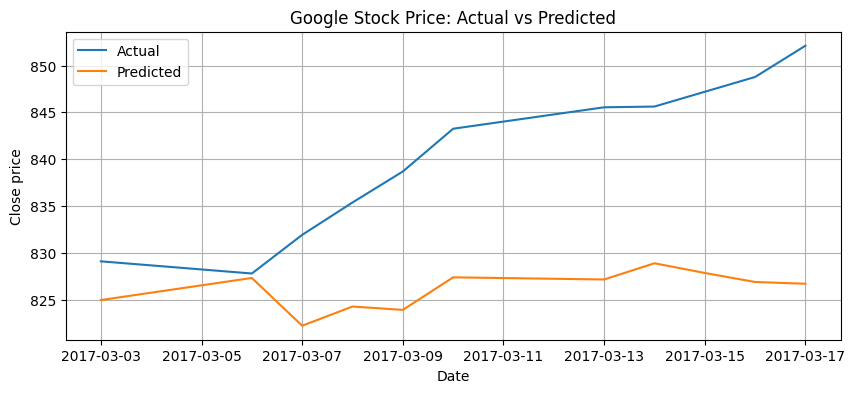

In [25]:
test_dates = data["Date"].iloc[LOOK_BACK + split_index:].reset_index(drop=True)

plt.figure(figsize=(10, 4))
plt.plot(test_dates, actual_prices, label="Actual")
plt.plot(test_dates, predicted_prices, label="Predicted")
plt.xlabel("Date")
plt.ylabel("Close price")
plt.title("Google Stock Price: Actual vs Predicted")
plt.legend()
plt.grid(True)
plt.show()

## Step 9: Predict the next closing price

This uses the last LOOK_BACK available prices as input. It is only a model estimate for learning.

In [26]:
last_prices = scaled_prices[-LOOK_BACK:].reshape(1, LOOK_BACK, 1)
next_scaled_price = model.predict(last_prices, verbose=0)
next_price = scaler.inverse_transform(next_scaled_price)[0][0]

print(f"Approx predicted next closing price: {next_price:.2f}")

Approx predicted next closing price: 827.52


## Conclusion

We created a SimpleRNN model for Google stock price prediction. The important part of time series modeling is creating ordered input sequences and testing on future data.